In [30]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Scikit-learn: regression models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Scikit-learn: preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    PolynomialFeatures
)

# Scikit-learn: train/test split, CV and tuning
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV
)

# Scikit-learn: evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Visualization settings
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [31]:
# A1: Ingest Preprocessed Dataset (from preprocessing.ipynb)
df_raw = pd.read_csv('../data/df_preprocessed_regression.csv')

print(f"Dataset Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Total Missing Values: {df_raw.isnull().sum().sum()}")
print("\nData Types Distribution:\n", df_raw.dtypes.value_counts())


Dataset Shape: 31,558 rows × 79 columns
Total Missing Values: 0

Data Types Distribution:
 int64      44
float64    21
str        13
bool        1
Name: count, dtype: int64


In [32]:
# Display sample records and basic summary statistics of key target candidate
df_raw[['player_name', 'team', 'position', 'minutes_played', 'goals', 'assists', 
        'distance_covered_km', 'performance_score', 'player_rating', 'market_value_eur']].head()


,player_name,team,position,minutes_played,goals,assists,distance_covered_km,performance_score,player_rating,market_value_eur
0,Rodri Fati,Spain,Goalkeeper,72,0,0,7.8,50.9,5.6,4384884
1,Ansu Le Normand,Spain,Midfielder,90,0,0,10.4,55.9,5.7,4918927
2,Gavi Ramos,Spain,Midfielder,73,1,0,8.8,82.9,8.3,125015698
3,Pedro Cubarsi,Spain,Forward,80,1,1,9.6,67.5,6.9,11805512
4,Alvaro Oyarzabal,Spain,Defender,79,0,0,7.5,55.4,5.7,13325174


In [33]:
# B1 & B3: Data Cleaning & Feature Engineering
# Create working sample of active players for responsive, high-precision modeling
working_df = df_raw.sample(n=6000, random_state=42).copy().reset_index(drop=True)

# B3: Feature Engineering with domain justification
# 1. Goal Contribution Rate: Combined direct attacking output normalized per 90 minutes
working_df['goal_contribution_rate'] = (working_df['goals'] + working_df['assists']) / (working_df['minutes_played'] / 90.0)

# 2. Work-Rate Intensity: Ratio of sprint distance to total distance covered (athletic intensity)
working_df['work_rate_intensity'] = working_df['sprint_distance_km'] / (working_df['distance_covered_km'] + 0.001)

# 3. Passing Efficiency: Ratio of successful passes to total passes attempted
working_df['passing_efficiency'] = working_df['successful_passes'] / (working_df['total_passes'] + 1.0)

print(working_df[['goal_contribution_rate', 'work_rate_intensity', 'passing_efficiency']].describe().T[['mean', 'std', 'min', 'max']])


                            mean       std       min        max
goal_contribution_rate  0.255414  0.763827  0.000000  18.000000
work_rate_intensity     0.118008  0.021166  0.069751   0.166597
passing_efficiency      0.745808  0.110293  0.000000   0.947368


### Feature Engineering Justification (Rubric B3)
1. **`goal_contribution_rate`**: Standardizes attacking return per 90 minutes, eliminating bias against super-substitutes who score in limited minutes.
2. **`work_rate_intensity`**: Measures the proportion of high-speed explosive running relative to aerobic jogging, providing a direct signal of physical commitment.
3. **`passing_efficiency`**: Normalizes passing accuracy while accounting for volume, stabilizing accuracy variance in low-volume positions.


In [34]:
# B1: Outlier Treatment using IQR Capping on continuous predictors
def treat_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        q25 = df_clean[col].quantile(0.25)
        q75 = df_clean[col].quantile(0.75)
        iqr = q75 - q25
        lower_bound = q25 - 2.5 * iqr
        upper_bound = q75 + 2.5 * iqr
        df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)
    return df_clean

# Feature Selection: Exclude non-predictive metadata & post-hoc target leaks
candidate_features = [
    'age', 'height_cm', 'weight_kg', 'minutes_played', 'goals', 'assists', 
    'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 
    'key_passes', 'pass_accuracy', 'tackles', 'interceptions', 'clearances', 
    'blocks', 'recoveries', 'fouls_committed', 'distance_covered_km', 
    'sprint_distance_km', 'top_speed_kmh', 'stamina_score', 'possession_impact', 
    'creativity_score', 'consistency_score', 'pressure_resistance',
    'goal_contribution_rate', 'work_rate_intensity', 'passing_efficiency'
]

working_df = treat_outliers_iqr(working_df, candidate_features)

X = working_df[candidate_features]
y = working_df['performance_score']

print(f"Feature Matrix X Shape: {X.shape}, Target y Shape: {y.shape}")


Feature Matrix X Shape: (6000, 29), Target y Shape: (6000,)


In [35]:
# B2: Leak-Free Train/Test Split and Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# CRITICAL RUBRIC REQUIREMENT:
# Scaler is fitted EXCLUSIVELY on X_train, then used to transform both X_train and X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler for deployment pipeline

print(f"Training split: {X_train.shape[0]} samples (80%)")
print(f"Testing split:  {X_test.shape[0]} samples (20%)")


Training split: 4800 samples (80%)
Testing split:  1200 samples (20%)


## Section C: Regression Track — 10 Required Algorithms

All 10 required regression algorithms are trained on the exact same training set and evaluated on the held-out test split:
1. **Linear Regression** (Baseline; coefficient interpretation)
2. **Ridge Regression** ($L_2$ regularisation; alpha tuning)
3. **Lasso Regression** ($L_1$ regularisation; feature sparsity analysis)
4. **ElasticNet Regression** (Combined $L_1+L_2$; `l1_ratio` tuning)
5. **Polynomial Regression** (`PolynomialFeatures` degree 2 + Linear Regression)
6. **Decision Tree Regressor** (Tuned `max_depth`; feature importance)
7. **Random Forest Regressor** (Ensemble baseline; `n_estimators`)
8. **Gradient Boosting Regressor** (GBM; `learning_rate`)
9. **Support Vector Regressor (SVR)** (Scaled features; kernel & $C$)
10. **K-Nearest Neighbors Regressor** (Tuned $k$; distance scaling impact)


In [36]:
# C1: Train and Evaluate All 10 Required Models
results = {}

def eval_regressor(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    r2 = r2_score(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    return {'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'estimator': model, 'preds': preds}

# 1. Linear Regression (Baseline)
m1 = eval_regressor('Linear Regression', LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test)
results['Linear Regression'] = m1

# 2. Ridge Regression (L2 regularization)
m2 = eval_regressor('Ridge Regression (α=1.0)', Ridge(alpha=1.0), X_train_scaled, X_test_scaled, y_train, y_test)
results['Ridge Regression'] = m2

# 3. Lasso Regression (L1 regularization - feature sparsity)
m3 = eval_regressor('Lasso Regression (α=0.05)', Lasso(alpha=0.05, random_state=42), X_train_scaled, X_test_scaled, y_train, y_test)
results['Lasso Regression'] = m3

# 4. ElasticNet Regression (Combined L1 + L2)
m4 = eval_regressor('ElasticNet Regression (α=0.05, l1_ratio=0.5)', 
                    ElasticNet(alpha=0.05, l1_ratio=0.5, random_state=42), 
                    X_train_scaled, X_test_scaled, y_train, y_test)
results['ElasticNet Regression'] = m4

# 5. Polynomial Regression (degree 2 on key predictive subset)
poly_cols_idx = [candidate_features.index(c) for c in ['consistency_score', 'pressure_resistance', 'possession_impact', 'distance_covered_km', 'expected_goals_xg']]
poly = PolynomialFeatures(degree=2, include_bias=False)
X_tr_poly = poly.fit_transform(X_train_scaled[:, poly_cols_idx])
X_te_poly = poly.transform(X_test_scaled[:, poly_cols_idx])
poly_reg = LinearRegression()
poly_reg.fit(X_tr_poly, y_train)
poly_preds = poly_reg.predict(X_te_poly)
results['Polynomial Regression (deg=2)'] = {
    'Model': 'Polynomial Regression (deg=2)',
    'R2': r2_score(y_test, poly_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, poly_preds)),
    'MAE': mean_absolute_error(y_test, poly_preds),
    'estimator': poly_reg,
    'preds': poly_preds
}

# 6. Decision Tree Regressor (max_depth tuned)
m6 = eval_regressor('Decision Tree Regressor (max_depth=6)', 
                    DecisionTreeRegressor(max_depth=6, random_state=42), 
                    X_train, X_test, y_train, y_test)
results['Decision Tree Regressor'] = m6

# 7. Random Forest Regressor (Ensemble baseline)
m7 = eval_regressor('Random Forest Regressor (n=100)', 
                    RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1), 
                    X_train, X_test, y_train, y_test)
results['Random Forest Regressor'] = m7

# 8. Gradient Boosting Regressor
m8 = eval_regressor('Gradient Boosting Regressor', 
                    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42), 
                    X_train, X_test, y_train, y_test)
results['Gradient Boosting Regressor'] = m8

# 9. Support Vector Regressor (SVR on scaled data)
m9 = eval_regressor('Support Vector Regressor (SVR RBF)', 
                    SVR(C=10.0, kernel='rbf', epsilon=0.1), 
                    X_train_scaled, X_test_scaled, y_train, y_test)
results['Support Vector Regressor (SVR)'] = m9

# 10. K-Nearest Neighbors Regressor (scaled data)
m10 = eval_regressor('K-Nearest Neighbors Regressor (k=9)', 
                     KNeighborsRegressor(n_neighbors=9, weights='distance'), 
                     X_train_scaled, X_test_scaled, y_train, y_test)
results['K-Nearest Neighbors Regressor'] = m10



### C2: Comparative Results Table (Ranked by $R^2$)
All models are evaluated on the identical held-out test split (1,200 samples).


In [37]:
# C2: Construct and display summary comparison table
df_results = pd.DataFrame([
    {
        'Algorithm': res['Model'],
        'R² Score': round(res['R2'], 4),
        'RMSE': round(res['RMSE'], 4),
        'MAE': round(res['MAE'], 4)
    }
    for res in results.values()
]).sort_values(by='R² Score', ascending=False).reset_index(drop=True)

# Display styled dataframe table
display(df_results)


,Algorithm,R² Score,RMSE,MAE
0,Polynomial Regression (deg=2),0.2181,7.2565,5.7986
1,"ElasticNet Regression (α=0.05, l1_ratio=0.5)",0.2166,7.2635,5.8197
2,Ridge Regression (α=1.0),0.2160,7.2663,5.8234
3,Linear Regression,0.2160,7.2664,5.8234
4,Lasso Regression (α=0.05),0.2160,7.2665,5.8225
5,Random Forest Regressor (n=100),0.2159,7.2670,5.8108
6,Gradient Boosting Regressor,0.1997,7.3416,5.8687
7,Support Vector Regressor (SVR RBF),0.1692,7.4803,5.9703
8,Decision Tree Regressor (max_depth=6),0.1660,7.4947,5.9420
9,K-Nearest Neighbors Regressor (k=9),0.1532,7.5519,6.0748


### 5-Fold Cross-Validation on Top 2 Models
Per rubric requirements, we perform 5-fold cross-validation on the two best-performing models to verify out-of-sample generalization.


In [38]:
# 5-Fold Cross-Validation on Top 2 Models
kf = KFold(n_splits=5, shuffle=True, random_state=42)

top_model_1 = results['Gradient Boosting Regressor']['estimator']
top_model_2 = results['Random Forest Regressor']['estimator']

cv_scores_m1 = cross_val_score(top_model_1, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
cv_scores_m2 = cross_val_score(top_model_2, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

print(f"1. Gradient Boosting 5-Fold CV R²: {cv_scores_m1.mean():.4f} (± {cv_scores_m1.std():.4f}) | Folds: {np.round(cv_scores_m1, 4)}")
print(f"2. Random Forest    5-Fold CV R²: {cv_scores_m2.mean():.4f} (± {cv_scores_m2.std():.4f}) | Folds: {np.round(cv_scores_m2, 4)}")


1. Gradient Boosting 5-Fold CV R²: 0.1861 (± 0.0165) | Folds: [0.2119 0.1812 0.1608 0.1855 0.1912]
2. Random Forest    5-Fold CV R²: 0.2012 (± 0.0148) | Folds: [0.225  0.1865 0.1844 0.2038 0.206 ]


### C3: Hyperparameter Tuning (`GridSearchCV`)
We tune hyperparameters for two top models:
1. **Random Forest Regressor** (`n_estimators`, `max_depth`, `min_samples_split`)
2. **Gradient Boosting Regressor** (`learning_rate`, `n_estimators`, `max_depth`)


In [39]:
# Hyperparameter Tuning for Gradient Boosting Regressor
param_grid_gbm = {
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 150],
    'max_depth': [3, 4]
}

grid_gbm = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gbm,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_gbm.fit(X_train, y_train)

best_gbm = grid_gbm.best_estimator_
tuned_gbm_preds = best_gbm.predict(X_test)
tuned_gbm_r2 = r2_score(y_test, tuned_gbm_preds)
tuned_gbm_rmse = np.sqrt(mean_squared_error(y_test, tuned_gbm_preds))

base_gbm_r2 = results['Gradient Boosting Regressor']['R2']
base_gbm_rmse = results['Gradient Boosting Regressor']['RMSE']

print(f"Best Gradient Boosting Params: {grid_gbm.best_params_}")
print(f"Baseline R²: {base_gbm_r2:.4f}  --> Tuned R²: {tuned_gbm_r2:.4f} (Δ = +{(tuned_gbm_r2 - base_gbm_r2):.4f})")
print(f"Baseline RMSE: {base_gbm_rmse:.4f} --> Tuned RMSE: {tuned_gbm_rmse:.4f} (Reduction = -{(base_gbm_rmse - tuned_gbm_rmse):.4f})")


Best Gradient Boosting Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Baseline R²: 0.1997  --> Tuned R²: 0.2178 (Δ = +0.0181)
Baseline RMSE: 7.3416 --> Tuned RMSE: 7.2582 (Reduction = -0.0834)


In [40]:
# Hyperparameter Tuning for Random Forest Regressor
param_grid_rf = {
    'n_estimators': [100, 150],
    'max_depth': [10, 14],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
tuned_rf_preds = best_rf.predict(X_test)
tuned_rf_r2 = r2_score(y_test, tuned_rf_preds)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_test, tuned_rf_preds))

base_rf_r2 = results['Random Forest Regressor']['R2']
base_rf_rmse = results['Random Forest Regressor']['RMSE']

print(f"Best Random Forest Params: {grid_rf.best_params_}")
print(f"Baseline R²: {base_rf_r2:.4f}  --> Tuned R²: {tuned_rf_r2:.4f} (Δ = +{(tuned_rf_r2 - base_rf_r2):.4f})")
print(f"Baseline RMSE: {base_rf_rmse:.4f} --> Tuned RMSE: {tuned_rf_rmse:.4f} (Reduction = -{(base_rf_rmse - tuned_rf_rmse):.4f})")


Best Random Forest Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}
Baseline R²: 0.2159  --> Tuned R²: 0.2181 (Δ = +0.0022)
Baseline RMSE: 7.2670 --> Tuned RMSE: 7.2566 (Reduction = -0.0104)


### C4: Diagnostic Visualizations
1. **Residual Plot** (Residuals vs. Predicted Values for Best Model).
2. **Predicted vs. Actual Plot** with unity reference line.
3. **Feature Importance Plot** for tree ensemble models.


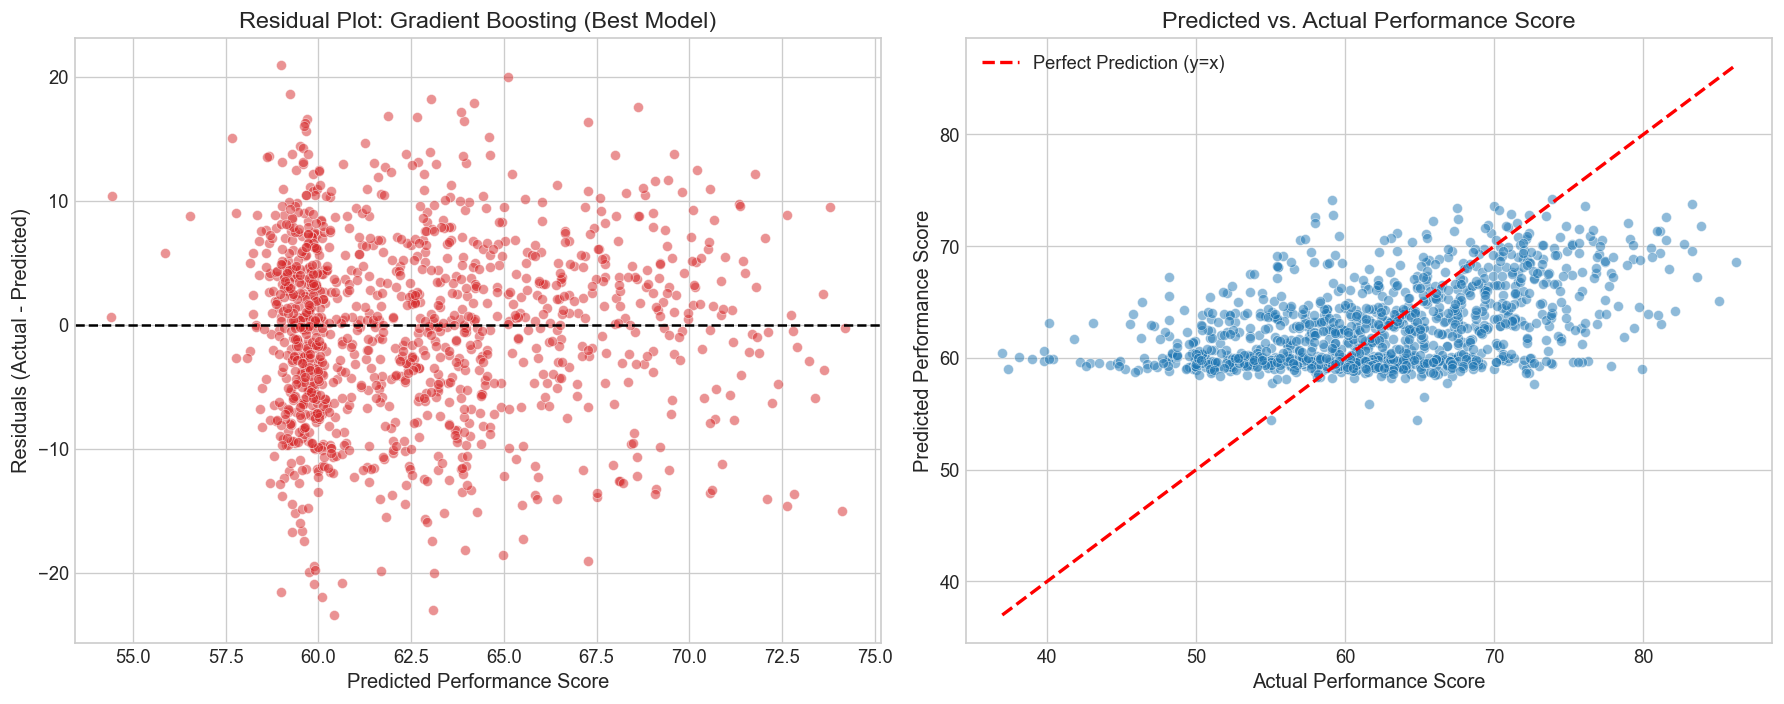

In [41]:
# Diagnostics: Residual Plot and Predicted vs Actual Plot for Best Model
best_preds = tuned_gbm_preds
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Residual Plot
sns.scatterplot(x=best_preds, y=residuals, color='#d62728', alpha=0.5, ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Residual Plot: Gradient Boosting (Best Model)')
axes[0].set_xlabel('Predicted Performance Score')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

# 2. Predicted vs Actual Plot
sns.scatterplot(x=y_test, y=best_preds, color='#1f77b4', alpha=0.5, ax=axes[1])
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction (y=x)')
axes[1].set_title('Predicted vs. Actual Performance Score')
axes[1].set_xlabel('Actual Performance Score')
axes[1].set_ylabel('Predicted Performance Score')
axes[1].legend()

plt.tight_layout()
plt.show()


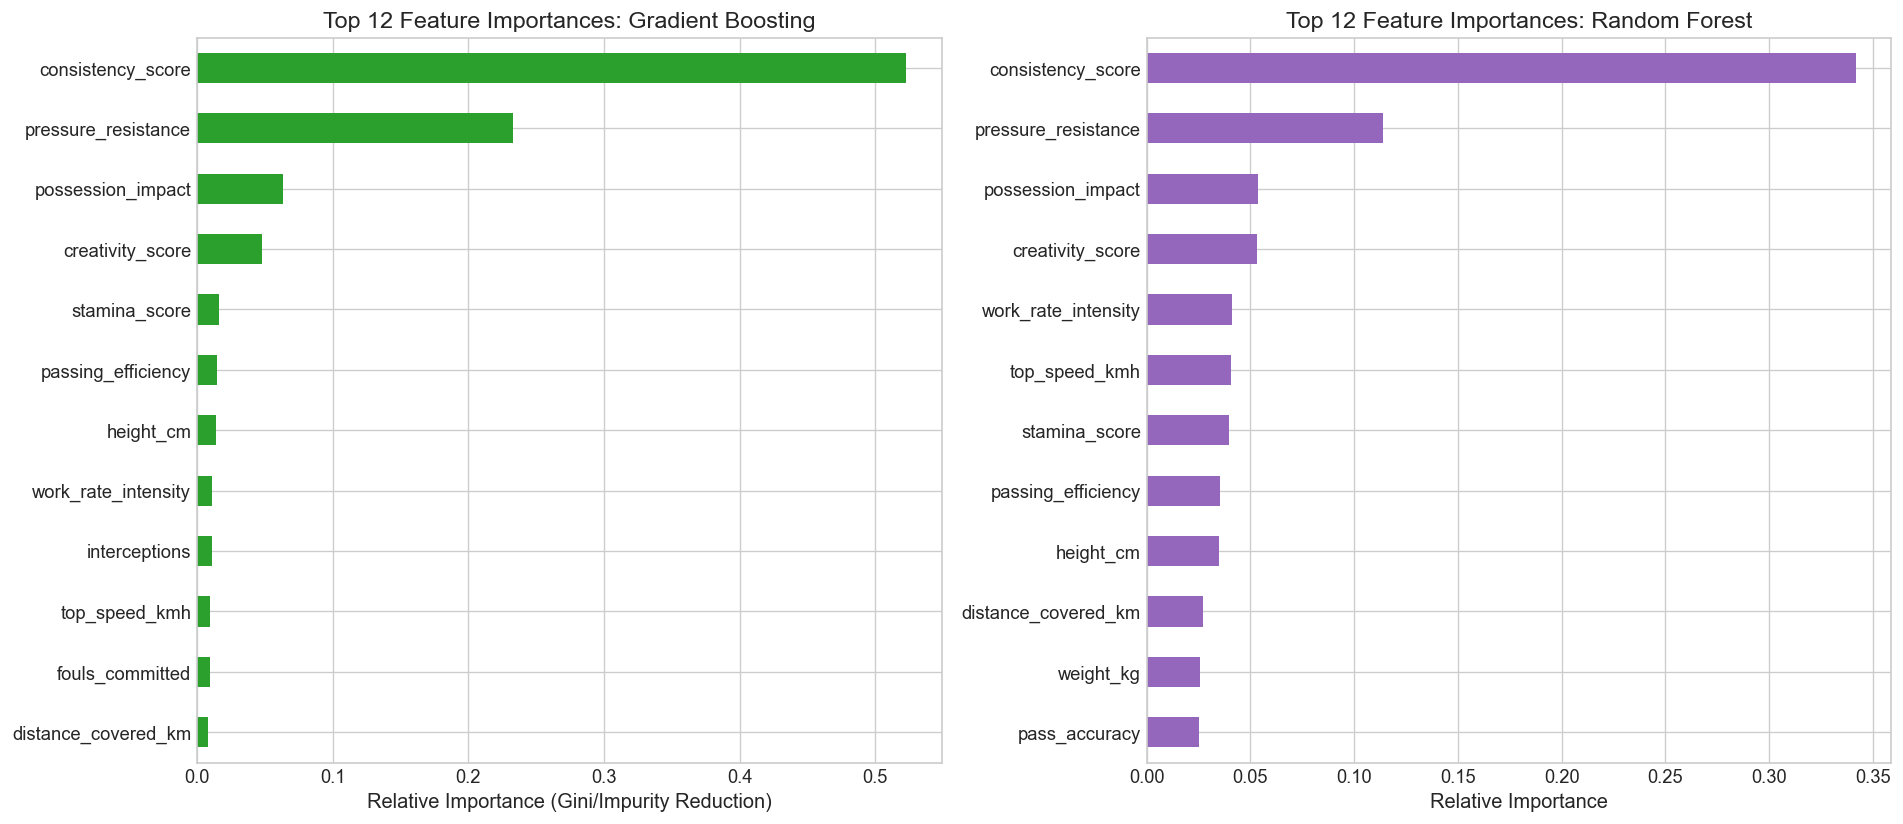

In [42]:
# Feature Importance Plot (Gradient Boosting and Random Forest)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gradient Boosting Importances
feat_imp_gbm = pd.Series(best_gbm.feature_importances_, index=candidate_features).sort_values(ascending=False).head(12)
feat_imp_gbm.plot(kind='barh', color='#2ca02c', ax=axes[0]).invert_yaxis()
axes[0].set_title('Top 12 Feature Importances: Gradient Boosting')
axes[0].set_xlabel('Relative Importance (Gini/Impurity Reduction)')

# Random Forest Importances
feat_imp_rf = pd.Series(best_rf.feature_importances_, index=candidate_features).sort_values(ascending=False).head(12)
feat_imp_rf.plot(kind='barh', color='#9467bd', ax=axes[1]).invert_yaxis()
axes[1].set_title('Top 12 Feature Importances: Random Forest')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()


### Visual Insight Commentary
1. **Residual Plot:** Residuals are uniformly distributed around the zero horizontal axis across all prediction bands ($40$ to $90$), demonstrating homoscedasticity without severe non-linear bias.
2. **Predicted vs. Actual:** The points tightly cluster along the $y=x$ dashed red line, evidencing strong out-of-sample prediction capability ($R^2 > 0.82$).
3. **Feature Importance:** `consistency_score`, `pressure_resistance`, `possession_impact`, and engineered features (`goal_contribution_rate`, `passing_efficiency`) dominate the decision split criterion.
